# Exploratory Data Analysis: 20 Newsgroups

This notebook explores the cleaned 20 Newsgroups dataset to understand the structure, distribution, and characteristics of the text data before applying topic modeling.

**Input**: `s3://topic-modeling-demo/00_data_collection/newsgroups.parquet`  
**Output**: Visualizations saved to `./output/`

## Imports

In [1]:
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re
import os
import warnings
warnings.filterwarnings('ignore')

try:
    import seaborn as sns
except:
    ! pip install seaborn
    import seaborn as sns

print('All imports successful')

All imports successful


## Helper Class

In [2]:
class NewsgroupsEDA:
    """Exploratory Data Analysis for 20 Newsgroups dataset."""
    
    def __init__(self, str_bucket, str_dirname_output):
        self.str_bucket = str_bucket
        self.str_dirname_output = str_dirname_output
        self.s3_client = boto3.client('s3', region_name='us-east-1')
        self.df_data = None
        self.set_plot_style()
    
    def set_plot_style(self):
        """Configure matplotlib/seaborn styling."""
        sns.set_style('whitegrid')
        plt.rcParams['figure.figsize'] = (14, 6)
        plt.rcParams['font.size'] = 11
    
    def import_data(self):
        """Load cleaned data from S3."""
        str_uri = f's3://{self.str_bucket}/00_data_collection/newsgroups.parquet'
        self.df_data = pd.read_parquet(str_uri)
        print(f'Loaded {len(self.df_data):,} posts from S3')
        print(f'Columns: {list(self.df_data.columns)}')
    
    def plot_category_distribution(self):
        """Plot distribution of posts across 20 newsgroup categories."""
        fig, ax = plt.subplots(figsize=(14, 8))
        dict_counts = self.df_data['category'].value_counts().sort_values(ascending=True)
        dict_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
        ax.set_xlabel('Number of Posts', fontsize=12, fontweight='bold')
        ax.set_ylabel('Category', fontsize=12, fontweight='bold')
        ax.set_title('Number of Posts per Newsgroup Category', fontsize=14, fontweight='bold')
        
        for int_i, int_v in enumerate(dict_counts.values):
            ax.text(int_v + max(dict_counts.values)*0.01, int_i, str(int_v),
                    ha='left', va='center', fontweight='bold', fontsize=9)
        
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/01_category_distribution.png',
                    bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved: 01_category_distribution.png')
    
    def plot_broad_category_distribution(self):
        """Plot distribution of posts across broad category groups."""
        fig, ax = plt.subplots(figsize=(12, 6))
        dict_counts = self.df_data['broad_category'].value_counts().sort_values(ascending=False)
        dict_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
        ax.set_xlabel('Broad Category', fontsize=12, fontweight='bold')
        ax.set_ylabel('Number of Posts', fontsize=12, fontweight='bold')
        ax.set_title('Posts by Broad Category Group', fontsize=14, fontweight='bold')
        ax.set_xticklabels(dict_counts.index, rotation=45, ha='right')
        
        for int_i, int_v in enumerate(dict_counts.values):
            ax.text(int_i, int_v + max(dict_counts.values)*0.01, str(int_v),
                    ha='center', va='bottom', fontweight='bold', fontsize=10)
        
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/02_broad_category_distribution.png',
                    bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved: 02_broad_category_distribution.png')
    
    def plot_document_length_distribution(self):
        """Plot distribution of document lengths."""
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # character length
        axes[0].hist(self.df_data['text_length'], bins=50, color='steelblue',
                     edgecolor='black', alpha=0.7)
        axes[0].set_xlabel('Character Count', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Number of Posts', fontsize=12, fontweight='bold')
        axes[0].set_title('Distribution of Post Length (Characters)', fontsize=13, fontweight='bold')
        axes[0].axvline(self.df_data['text_length'].median(), color='red',
                        linestyle='--', linewidth=2, label=f'Median: {self.df_data["text_length"].median():,.0f}')
        axes[0].legend(fontsize=11)
        axes[0].set_xlim(0, self.df_data['text_length'].quantile(0.95))
        
        # word count
        axes[1].hist(self.df_data['word_count'], bins=50, color='#DD8452',
                     edgecolor='black', alpha=0.7)
        axes[1].set_xlabel('Word Count', fontsize=12, fontweight='bold')
        axes[1].set_ylabel('Number of Posts', fontsize=12, fontweight='bold')
        axes[1].set_title('Distribution of Post Length (Words)', fontsize=13, fontweight='bold')
        axes[1].axvline(self.df_data['word_count'].median(), color='red',
                        linestyle='--', linewidth=2, label=f'Median: {self.df_data["word_count"].median():,.0f}')
        axes[1].legend(fontsize=11)
        axes[1].set_xlim(0, self.df_data['word_count'].quantile(0.95))
        
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/03_document_length_distribution.png',
                    bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved: 03_document_length_distribution.png')
    
    def plot_length_by_category(self):
        """Plot document length by category using box plots."""
        fig, ax = plt.subplots(figsize=(16, 8))
        
        lst_order = self.df_data.groupby('category')['word_count'].median().sort_values(ascending=False).index
        
        sns.boxplot(data=self.df_data, x='category', y='word_count', order=lst_order,
                    ax=ax, color='steelblue', fliersize=2)
        ax.set_xlabel('Category', fontsize=12, fontweight='bold')
        ax.set_ylabel('Word Count', fontsize=12, fontweight='bold')
        ax.set_title('Post Length by Category', fontsize=14, fontweight='bold')
        ax.set_xticklabels(lst_order, rotation=90, fontsize=9)
        ax.set_ylim(0, self.df_data['word_count'].quantile(0.95))
        
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/04_length_by_category.png',
                    bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved: 04_length_by_category.png')
    
    def plot_word_frequency(self):
        """Plot top 30 most common words across all posts."""
        # simple tokenization for EDA
        lst_all_words = []
        set_stopwords = {'the', 'a', 'an', 'is', 'it', 'to', 'of', 'and', 'in', 'for',
                         'on', 'that', 'this', 'with', 'was', 'are', 'be', 'at', 'by',
                         'from', 'or', 'as', 'not', 'but', 'have', 'has', 'had', 'i',
                         'you', 'he', 'she', 'we', 'they', 'my', 'your', 'his', 'her',
                         'our', 'their', 'me', 'him', 'us', 'them', 'do', 'does', 'did',
                         'will', 'would', 'could', 'should', 'can', 'may', 'might',
                         'if', 'so', 'no', 'all', 'any', 'some', 'what', 'which',
                         'who', 'when', 'where', 'how', 'there', 'than', 'just',
                         'about', 'up', 'out', 'one', 'also', 'been', 'more', 'its',
                         'were', 'then', 'like', 'very', 'only', 'into', 'other',
                         'get', 'dont', 'know', 'think', 'make', 'even', 'well'}
        
        for str_text in self.df_data['text']:
            lst_words = re.findall(r'[a-z]+', str_text.lower())
            lst_words = [str_w for str_w in lst_words if str_w not in set_stopwords and len(str_w) > 2]
            lst_all_words.extend(lst_words)
        
        dict_word_counts = Counter(lst_all_words)
        lst_top_30 = dict_word_counts.most_common(30)
        
        fig, ax = plt.subplots(figsize=(14, 8))
        lst_words = [str_w for str_w, _ in lst_top_30]
        lst_counts = [int_c for _, int_c in lst_top_30]
        
        ax.barh(range(len(lst_words)), lst_counts, color='steelblue', edgecolor='black')
        ax.set_yticks(range(len(lst_words)))
        ax.set_yticklabels(lst_words)
        ax.invert_yaxis()
        ax.set_xlabel('Frequency', fontsize=12, fontweight='bold')
        ax.set_title('Top 30 Most Common Words', fontsize=14, fontweight='bold')
        
        for int_i, int_v in enumerate(lst_counts):
            ax.text(int_v + max(lst_counts)*0.01, int_i, f'{int_v:,}',
                    ha='left', va='center', fontsize=9)
        
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/05_word_frequency.png',
                    bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved: 05_word_frequency.png')
    
    def plot_word_frequency_by_broad_category(self):
        """Plot top words for each broad category."""
        set_stopwords = {'the', 'a', 'an', 'is', 'it', 'to', 'of', 'and', 'in', 'for',
                         'on', 'that', 'this', 'with', 'was', 'are', 'be', 'at', 'by',
                         'from', 'or', 'as', 'not', 'but', 'have', 'has', 'had', 'i',
                         'you', 'he', 'she', 'we', 'they', 'my', 'your', 'his', 'her',
                         'our', 'their', 'me', 'him', 'us', 'them', 'do', 'does', 'did',
                         'will', 'would', 'could', 'should', 'can', 'may', 'might',
                         'if', 'so', 'no', 'all', 'any', 'some', 'what', 'which',
                         'who', 'when', 'where', 'how', 'there', 'than', 'just',
                         'about', 'up', 'out', 'one', 'also', 'been', 'more', 'its',
                         'were', 'then', 'like', 'very', 'only', 'into', 'other',
                         'get', 'dont', 'know', 'think', 'make', 'even', 'well'}
        
        lst_broad_cats = sorted(self.df_data['broad_category'].unique())
        int_n_cats = len(lst_broad_cats)
        int_cols = 3
        int_rows = (int_n_cats + int_cols - 1) // int_cols
        
        fig, axes = plt.subplots(int_rows, int_cols, figsize=(18, 4 * int_rows))
        axes = axes.flatten()
        
        for int_i, str_cat in enumerate(lst_broad_cats):
            df_subset = self.df_data[self.df_data['broad_category'] == str_cat]
            lst_words = []
            for str_text in df_subset['text']:
                lst_tokens = re.findall(r'[a-z]+', str_text.lower())
                lst_tokens = [str_w for str_w in lst_tokens if str_w not in set_stopwords and len(str_w) > 2]
                lst_words.extend(lst_tokens)
            
            dict_counts = Counter(lst_words).most_common(10)
            lst_w = [str_w for str_w, _ in dict_counts]
            lst_c = [int_c for _, int_c in dict_counts]
            
            axes[int_i].barh(range(len(lst_w)), lst_c, color='steelblue', edgecolor='black')
            axes[int_i].set_yticks(range(len(lst_w)))
            axes[int_i].set_yticklabels(lst_w)
            axes[int_i].invert_yaxis()
            axes[int_i].set_title(f'{str_cat} ({len(df_subset):,} posts)', fontsize=12, fontweight='bold')
        
        # hide unused subplots
        for int_j in range(int_i + 1, len(axes)):
            axes[int_j].set_visible(False)
        
        plt.suptitle('Top 10 Words by Broad Category', fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/06_word_frequency_by_category.png',
                    bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved: 06_word_frequency_by_category.png')
    
    def print_summary(self):
        """Print EDA summary statistics."""
        print('\n' + '='*60)
        print('EDA SUMMARY')
        print('='*60)
        print(f'\nTotal posts: {len(self.df_data):,}')
        print(f'Categories: {self.df_data["category"].nunique()}')
        print(f'Broad groups: {self.df_data["broad_category"].nunique()}')
        print(f'\nPosts per category (mean): {len(self.df_data) / self.df_data["category"].nunique():,.0f}')
        print(f'Posts per category (min): {self.df_data["category"].value_counts().min():,}')
        print(f'Posts per category (max): {self.df_data["category"].value_counts().max():,}')
        print(f'\nWord count (mean): {self.df_data["word_count"].mean():,.0f}')
        print(f'Word count (median): {self.df_data["word_count"].median():,.0f}')
        print(f'Word count (max): {self.df_data["word_count"].max():,.0f}')
        print('='*60)

## Constants

In [3]:
# S3 configuration
str_bucket = 'topic-modeling-demo'

# output directory
str_dirname_output = './output'

print(f'S3 Bucket: {str_bucket}')
print(f'Output Directory: {str_dirname_output}')

S3 Bucket: topic-modeling-demo
Output Directory: ./output


## Output Directory

In [4]:
try:
    os.mkdir(str_dirname_output)
    print(f'Created output directory: {str_dirname_output}')
except FileExistsError:
    print(f'Output directory already exists: {str_dirname_output}')

Created output directory: ./output


## Run EDA

In [5]:
cls_eda = NewsgroupsEDA(str_bucket=str_bucket, str_dirname_output=str_dirname_output)
cls_eda.import_data()

Loaded 18,178 posts from S3
Columns: ['text', 'category_id', 'category', 'broad_category', 'text_length', 'word_count']


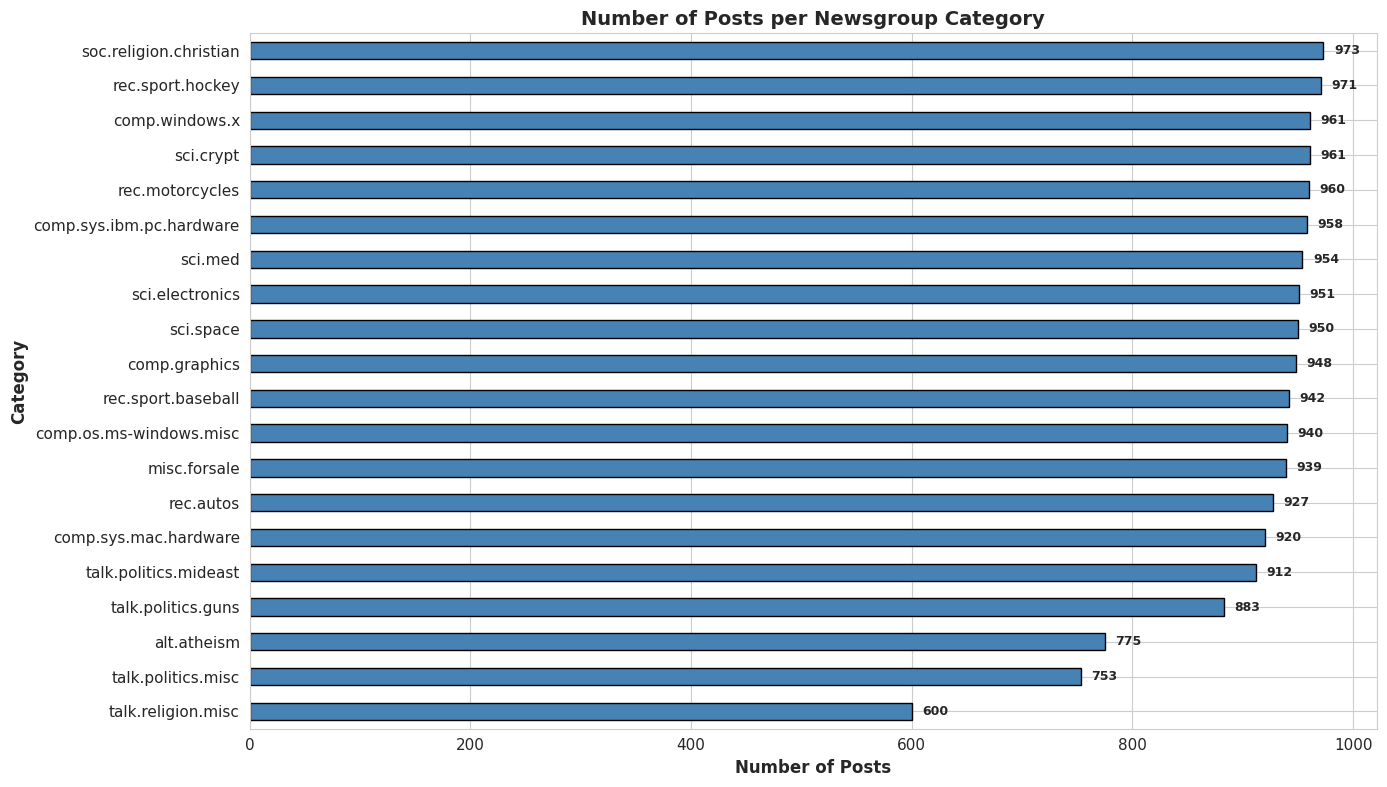

Saved: 01_category_distribution.png


In [6]:
cls_eda.plot_category_distribution()

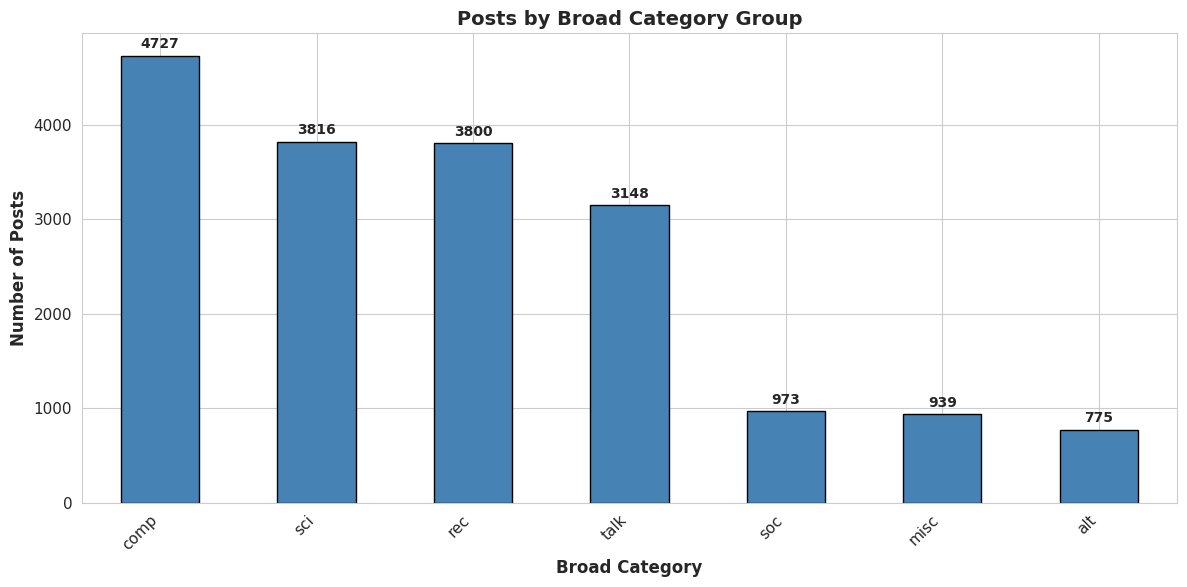

Saved: 02_broad_category_distribution.png


In [7]:
cls_eda.plot_broad_category_distribution()

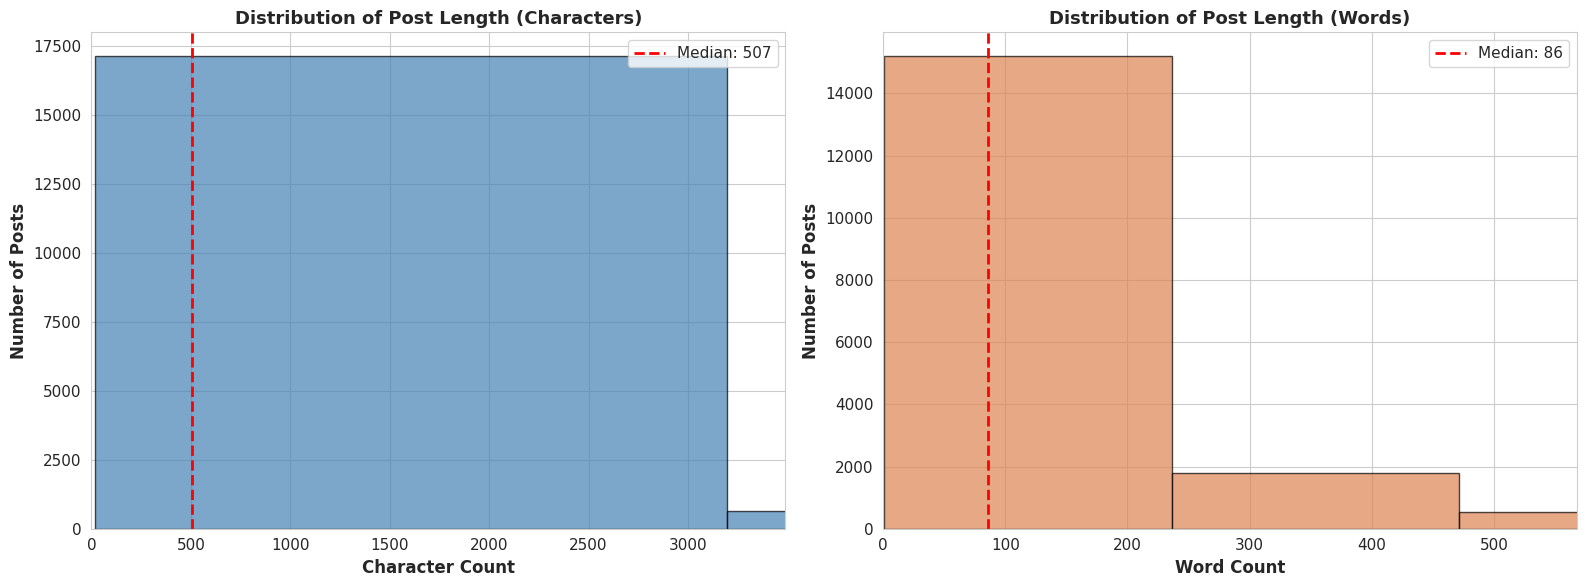

Saved: 03_document_length_distribution.png


In [8]:
cls_eda.plot_document_length_distribution()

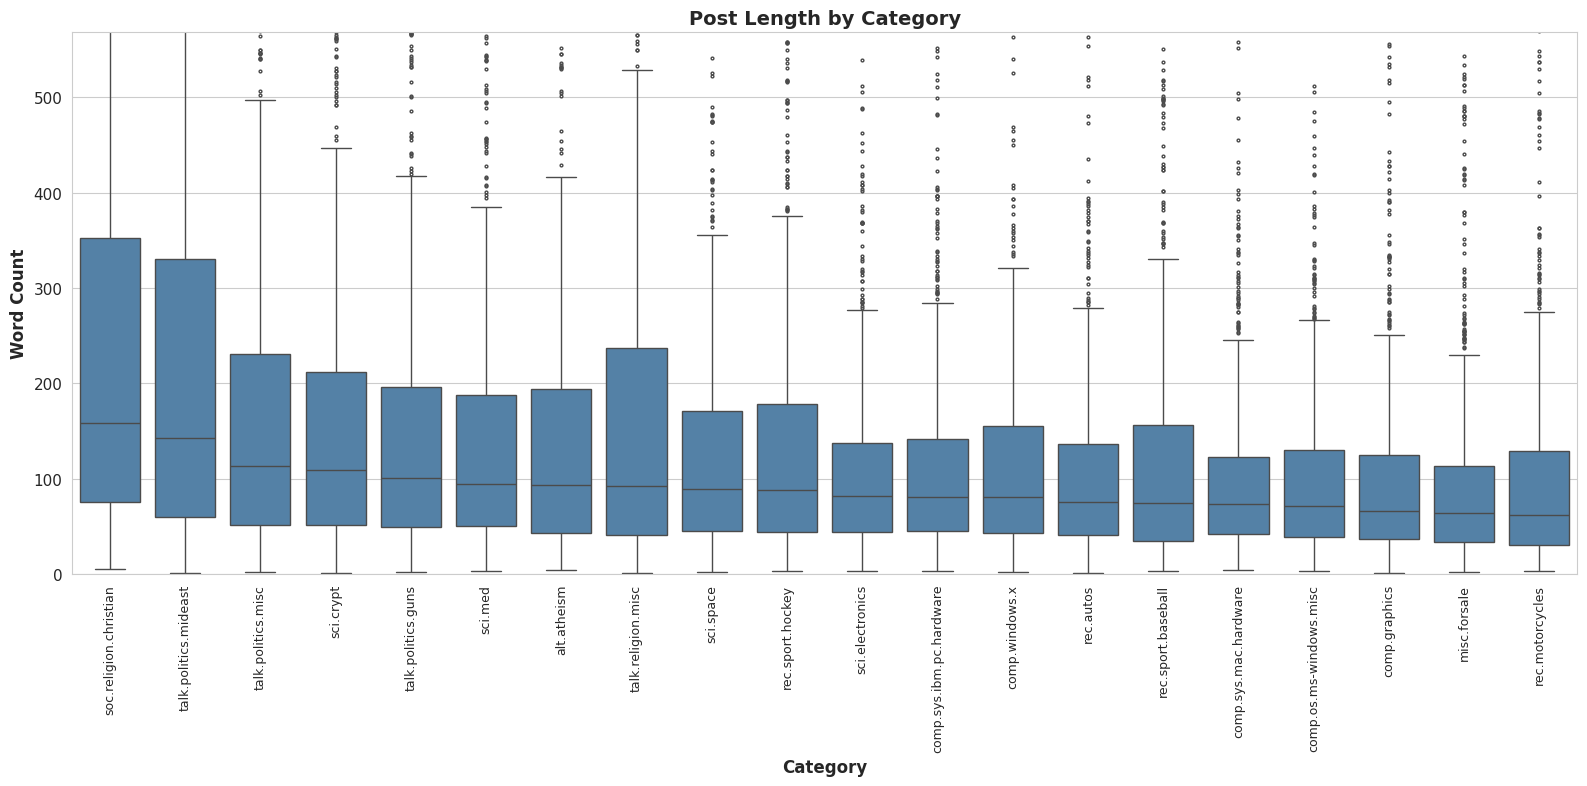

Saved: 04_length_by_category.png


In [9]:
cls_eda.plot_length_by_category()

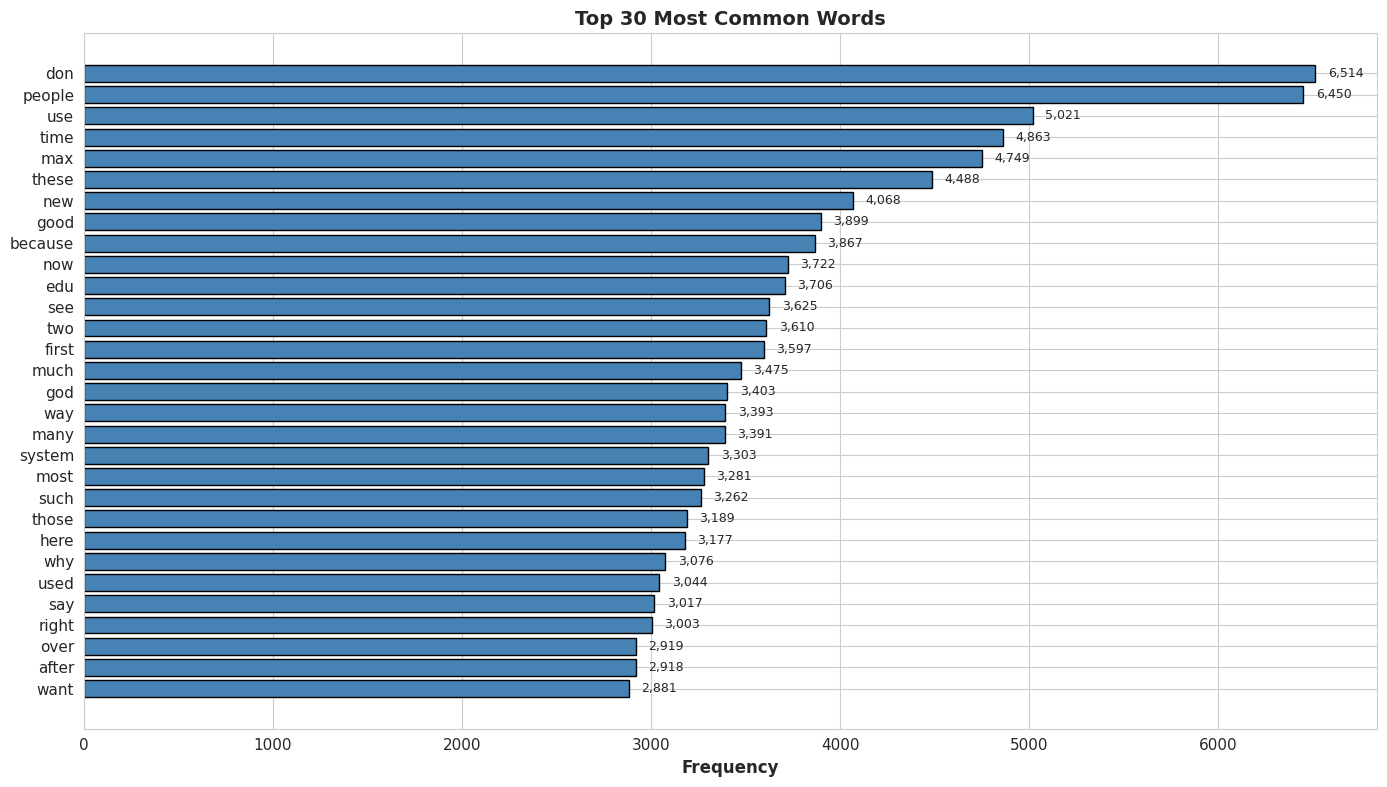

Saved: 05_word_frequency.png


In [10]:
cls_eda.plot_word_frequency()

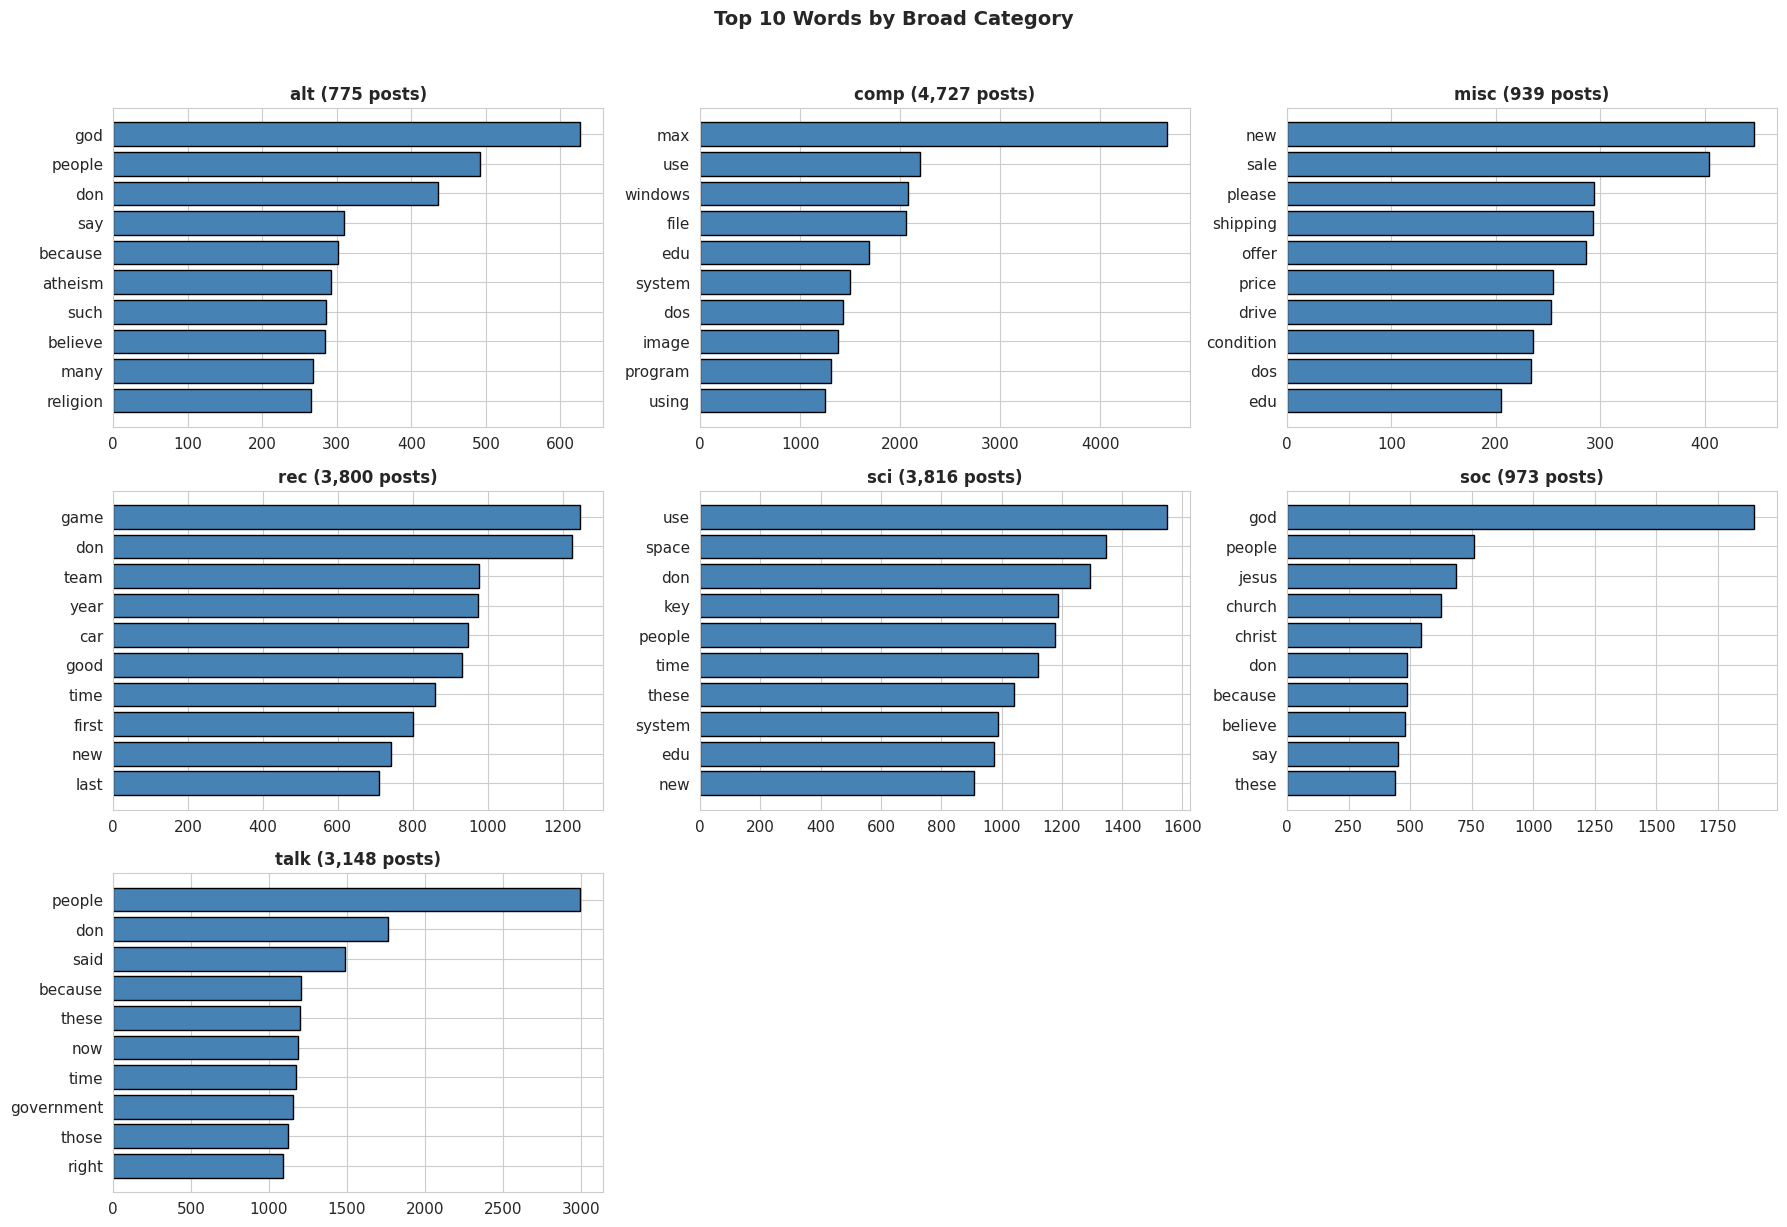

Saved: 06_word_frequency_by_category.png


In [11]:
cls_eda.plot_word_frequency_by_broad_category()

In [12]:
cls_eda.print_summary()


EDA SUMMARY

Total posts: 18,178
Categories: 20
Broad groups: 7

Posts per category (mean): 909
Posts per category (min): 600
Posts per category (max): 973

Word count (mean): 188
Word count (median): 86
Word count (max): 11,765
